In [ ]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from tqdm import tqdm 
import matplotlib.pyplot as plt

In [2]:
# Strain path generator

from Strain_curve_generator import strain_curve_generator

# Dataset sizes
su = 70000     # total number of generated data before modification
domain = 0.2


# Data containers
X_total = [np.zeros((6, 100)) for _ in range(su)]

# Generate full dataset
for i in range(su):
    x, y, z     = strain_curve_generator(domain , 'normal')
    xy, yz, xz  = strain_curve_generator(domain , 'shear')
    X_total[i][0, :] = x
    X_total[i][1, :] = y
    X_total[i][2, :] = z
    X_total[i][3, :] = xy
    X_total[i][4, :] = yz
    X_total[i][5, :] = xz

print('X_total =', np.shape(X_total))

X_total = (70000, 6, 100)


In [3]:
# stress and damage calculator

from  Path_Modifier import modifier_default

# choose your material
Materials = ['Steel' , 'Aluminum_AA7075_T6', 'Aluminum_notched_bar', 'Aluminum_flat_grooved']

material = Materials[0]

X_total_mod , Y_total_mod , num_total_data = modifier_default(X_total , su , material)


N = 2423
num_total_data = 2000


In [5]:
# Split into train, test, and validation

train_end = int(0.8 * num_total_data)
test_end = train_end + int(0.1 * num_total_data)

Y_train_mod = Y_total_mod[:train_end]
Y_test_mod = Y_total_mod[train_end:test_end]
Y_valid_mod = Y_total_mod[test_end:num_total_data ]

X_train_mod = X_total_mod[:train_end]
X_test_mod = X_total_mod[train_end:test_end]
X_valid_mod = X_total_mod[test_end:num_total_data ]

print('Y_train_mod = ',np.shape(Y_train_mod))
print('Y_test_mod = ',np.shape(Y_test_mod))
print('Y_valid_mod = ',np.shape(Y_valid_mod))

Y_train_mod =  (1600, 7, 100)
Y_test_mod =  (200, 7, 100)
Y_valid_mod =  (200, 7, 100)


In [7]:
# Hyperparameters

input_size = 7
output_size = 7
num_hidden_units = 600
num_epochs = 7000
batch_size = 32
alpha0 = 0.0008
tau = 20
gamma = 0.99
dropout = 0.0

# Dummy data placeholders (replace with actual preprocessed tensors)
X_train_tens = torch.tensor(np.array(X_train_mod), dtype=torch.float32).transpose(1, 2)  # shape: (N, T, 6)
Y_train_tens = torch.tensor(np.array(Y_train_mod), dtype=torch.float32).transpose(1, 2)  # shape: (N, T, 8)
X_valid_tens = torch.tensor(np.array(X_valid_mod), dtype=torch.float32).transpose(1, 2)
Y_valid_tens = torch.tensor(np.array(Y_valid_mod), dtype=torch.float32).transpose(1, 2)
X_test_tens  = torch.tensor(np.array(X_test_mod), dtype=torch.float32).transpose(1, 2)
Y_test_tens  = torch.tensor(np.array(Y_test_mod), dtype=torch.float32).transpose(1, 2)

# Dataset and Dataloader
train_dataset = TensorDataset(X_train_tens, Y_train_tens)
valid_dataset = TensorDataset(X_valid_tens, Y_valid_tens)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size)



# Define the model
class GRUNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout):
        super(GRUNet, self).__init__()
        self.gru1 = nn.GRU(input_size, hidden_size, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.gru2 = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        self.gru3 = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout3 = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x, _ = self.gru1(x)
        x = self.dropout1(x)
        x, _ = self.gru2(x)
        x = self.dropout2(x)
        x, _ = self.gru3(x)
        x = self.dropout3(x)
        x = self.fc(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device = cuda' if torch.cuda.is_available() else 'device = cpu')
model = GRUNet(input_size, num_hidden_units, output_size , dropout).to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=alpha0, betas=(0.9, 0.999), eps=1e-8, weight_decay=0) # weight decay (L2 penalty)  #https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=tau, gamma=gamma) #variable learning rate, every tau epochs



device = cuda


##  Train

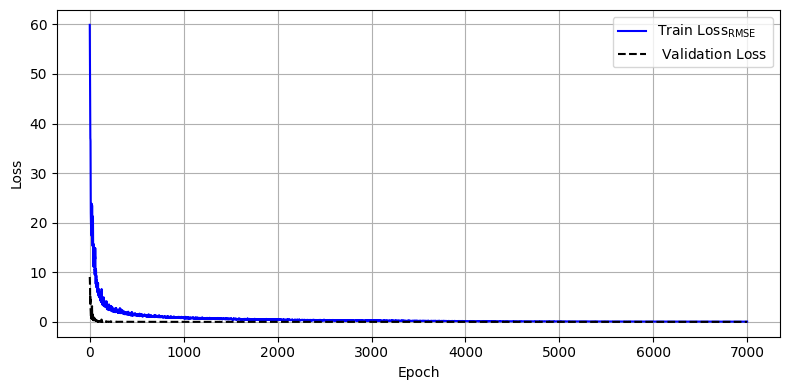

Epoch 7000/7000 - Train Loss: 0.0511,  Valid Loss: 0.0019, lr: 0.0000237


In [8]:
from IPython.display import clear_output
import matplotlib.pyplot as plt


# Initialize losses
train_losses = []
valid_losses = []
lr_vec = []



for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    
    
    for (xb, yb) in tqdm(train_loader, total=len(train_loader), desc=f"Training Epoch {epoch+1}"):   # xb = x_batch

        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()

        pred = model(xb)  # pred: [B, 100, 8] → output at time step n+1
        loss = criterion(pred, yb)  # Main loss (MSE)
        loss = torch.sqrt(loss)   # RMSE

        # backpropagation
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()

        
    train_losses.append(train_loss)

    scheduler.step()
    
    for param_group in optimizer.param_groups:
        lrate = param_group['lr']
        #print("Current LR:", lrate)
        lr_vec.append(lrate)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in valid_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            val_loss += loss.item()
    
    valid_losses.append(val_loss)

    # Plot update using clear_output
    clear_output(wait=True)
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses,       color='blue',   label=r'Train $\text{Loss}_{\text{RMSE}}$')
    plt.plot(valid_losses, '--', color='black', label=r' $ \text{Validation Loss}$')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f},  Valid Loss: {val_loss:.4f}, lr: {lrate:.7f}")



In [ ]:
import os
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

save_path_plot_default = r"D:\Python\vsCode\PINN\plots_default"
plt.figure(figsize=(8, 4))
plt.plot(train_losses,       color='blue',   label=r'Train $\text{Loss}_{\text{RMSE}}$')
plt.plot(valid_losses, '--', color='black', label=r' $ \text{Validation Loss}$')
plt.xlabel('Epoch',fontsize=20)
plt.ylabel('Loss',fontsize=20)
plt.legend(fontsize=20)
plt.tight_layout()
plt.tick_params(axis='both', labelsize=14)
#plt.savefig(os.path.join(save_path_plot_default, "plot_loss_default.svg"), format='svg')
plt.show()


## Save

In [9]:
import pickle


model_filename = f"Model_GRU_{num_epochs}Epock_default_{material}.pth"
session_vars_filename = f"session_vars_default_{material}.pkl"


torch.save(model.state_dict(), model_filename)

with open(session_vars_filename , 'wb') as f:
    pickle.dump({
        'train_losses': train_losses,
        'valid_losses': valid_losses,
        'lr_vec': lr_vec,
        'num_epochs': num_epochs,
        'Y_train_mod': Y_train_mod,
        'Y_test_mod': Y_test_mod,
        'Y_valid_mod': Y_valid_mod,
        'X_train_mod': X_train_mod,
        'X_test_mod': X_test_mod,
        'X_valid_mod': X_valid_mod,
        'input_size': input_size,
        'output_size': output_size,
        'num_hidden_units': num_hidden_units
        
    }, f)



## Inference

input =  tensor([-0.0264,  0.0672, -0.0562,  0.1579,  0.0048, -0.0120,  0.0473],
       device='cuda:0')
target =  [-2.3697243  -2.0453515  -2.5425198   2.837495    0.06173751 -0.2678639
  0.13628735]


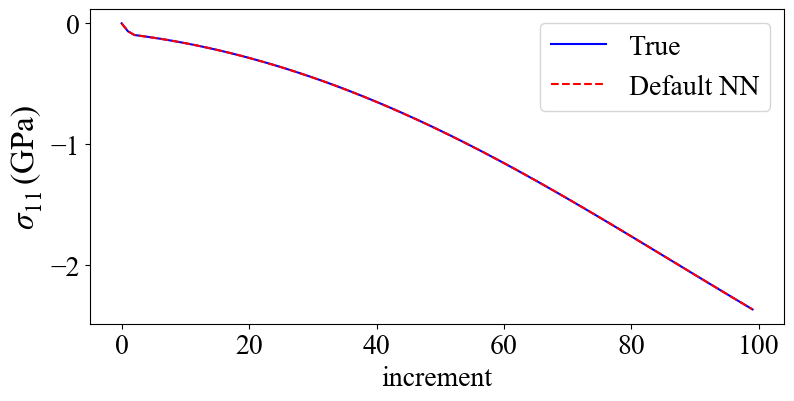

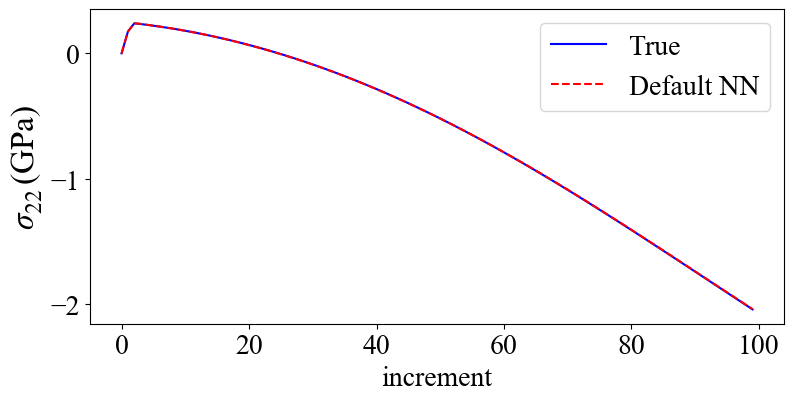

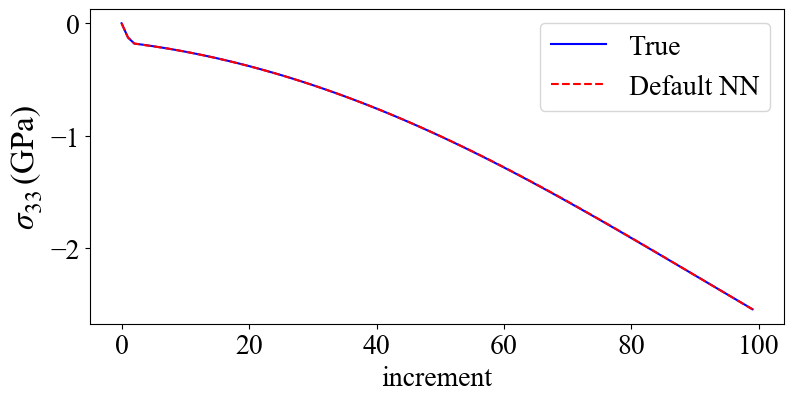

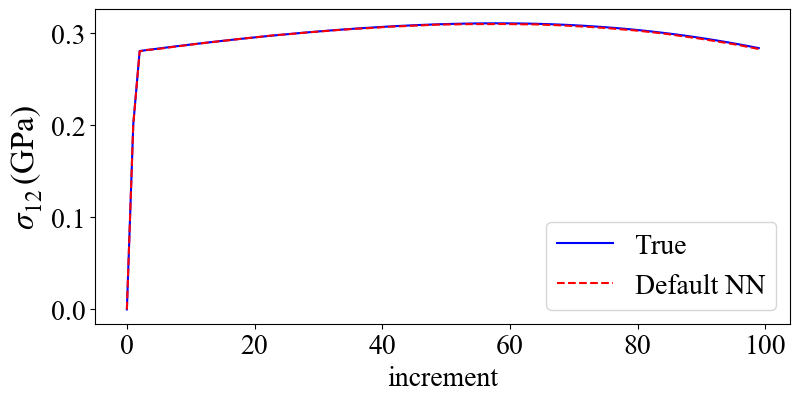

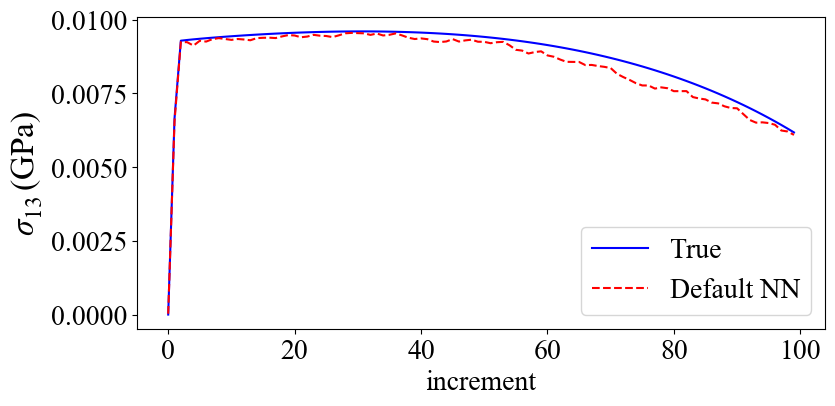

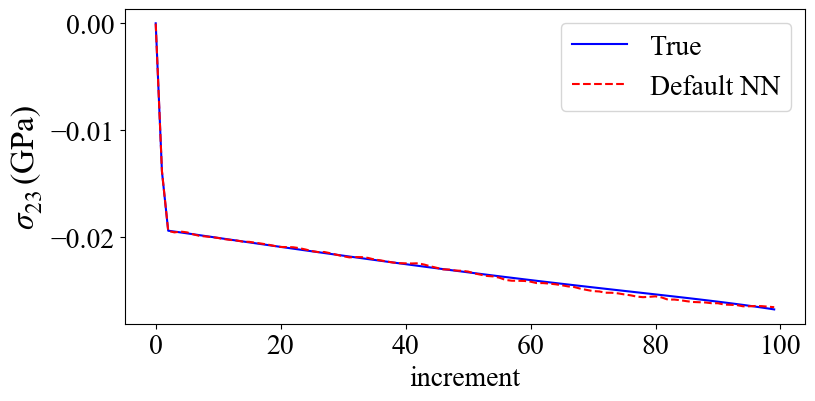

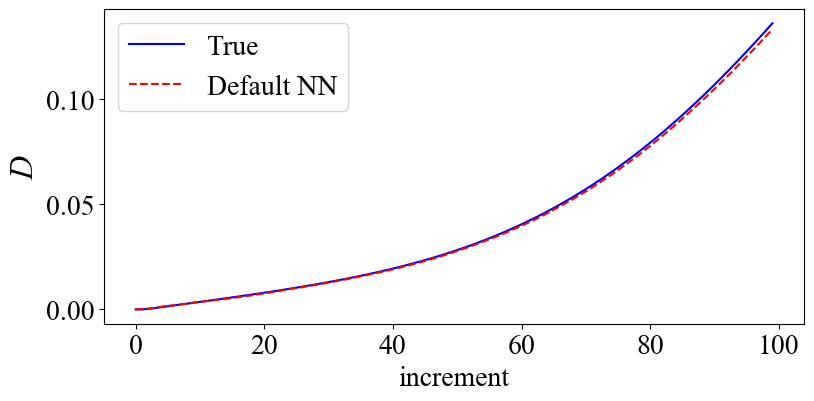

In [2]:
#  Inference inside trained domain

import matplotlib.pyplot as plt
import os
save_path_plot_default = r"D:\Python\vsCode\PINN\plots_default"

model.eval()


# Pick a sample from test data
sample_index = random.randint(1, len(X_test_mod)-1)
x_input =  X_test_tens[sample_index].unsqueeze(0).to(device)  # Shape: (1, T, 7)
y_target = Y_test_tens[sample_index].cpu().numpy()           # Shape: (T, 7)

print(  'input = ', x_input[0][-1])
print( 'target = ', y_target[-1,:])


# Run model prediction
with torch.no_grad():
    y_pred = model(x_input)  # Shape: (1, T, 7)
    y_pred = y_pred.squeeze(0).cpu().numpy()  # Shape: (T, 7)

# back shear components to GPa
y_target[: , 3:6 ] /= 10
y_pred[: , 3:6 ] /= 10

plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
plt.rcParams['font.family'] = 'Times New Roman'

labels = [r'$\sigma_{11}\,(\mathrm{GPa})$', r'$\sigma_{22}\,(\mathrm{GPa})$', r'$\sigma_{33}\,(\mathrm{GPa})$', r'$\sigma_{12}\,(\mathrm{GPa})$', r'$\sigma_{13}\,(\mathrm{GPa})$', r'$\sigma_{23}\,(\mathrm{GPa})$', r'$D$']

for i in range(7):
    plt.figure(figsize=(8, 4))
    plt.plot(y_target[:, i], label='True', color='blue')
    plt.plot(y_pred[:, i],'--', label='Default NN', color='red')
    plt.xlabel('increment',fontsize=20)
    plt.ylabel(labels[i],fontsize=24)
    plt.legend(fontsize=20)
    plt.tight_layout()
    plt.tick_params(axis='both', labelsize=20)
    filename = os.path.join(save_path_plot_default, f"plot_default_{i}.svg")
    #plt.savefig(filename, format='svg', bbox_inches='tight')
    plt.show()


###  Compaire PINN & Default NN

In [6]:
# call PINN

model_pinn = GRUNet(input_size, num_hidden_units, output_size).to(device)


if material == 'Steel':
    model_filename = "Model_GRU_7000Epock_PINN_Steel.pth"

elif material == 'Aluminum_AA7075_T6':
    model_filename = "Model_GRU_7000Epock_PINN_Aluminum_AA7075_T6.pth"
    
elif material == 'Aluminum_notched_bar':
    model_filename = "Model_GRU_7000Epock_PINN_Aluminum_notched.pth"
    
elif material == 'Aluminum_flat_grooved':
    model_filename = "Model_GRU_7000Epock_PINN_Aluminum_grooved.pth"

#Load weights
model_pinn.load_state_dict(torch.load(model_filename))
model_pinn.eval()

GRUNet(
  (gru1): GRU(7, 600, batch_first=True)
  (gru2): GRU(600, 600, batch_first=True)
  (gru3): GRU(600, 600, batch_first=True)
  (fc): Linear(in_features=600, out_features=7, bias=True)
)

In [7]:
# generate test data - out of trained region ( starin > 0.2 ) ]
# Note: some points may still lie within the trained domain

from Strain_curve_generator import strain_curve_generator
from  Path_Modifier import modifier_default

num = 300000 
outDoamin = 0.4

X_test_outDoamin = [np.zeros((6, 100)) for _ in range(num)]

for i in range(num):
    x, y, z    = strain_curve_generator(outDoamin, 'normal')
    xy, yz, xz = strain_curve_generator(outDoamin, 'shear')
    X_test_outDoamin[i][0, :] = x
    X_test_outDoamin[i][1, :] = y
    X_test_outDoamin[i][2, :] = z
    X_test_outDoamin[i][3, :] = xy
    X_test_outDoamin[i][4, :] = yz
    X_test_outDoamin[i][5, :] = xz


X_test_outDoamin_mod , Y_test_outDoamin_mod , num_outDoamin_data = modifier_default(X_test_outDoamin , num , material)

if num_outDoamin_data > 0 :
    X_test_outDoamin_tens = torch.tensor(np.array(X_test_outDoamin_mod), dtype=torch.float32).to(device).transpose(1, 2)
    Y_test_outDoamin_tens = torch.tensor(np.array(Y_test_outDoamin_mod), dtype=torch.float32).to(device).transpose(1, 2)
else:
    print('Not Enough Data! Increase (num)')

N = 1592
num_total_data = 1000


sample_index = 381
input =  tensor([-0.3979,  0.3825,  0.0083, -0.0371, -0.0085,  0.3902,  0.4061],
       device='cuda:0')


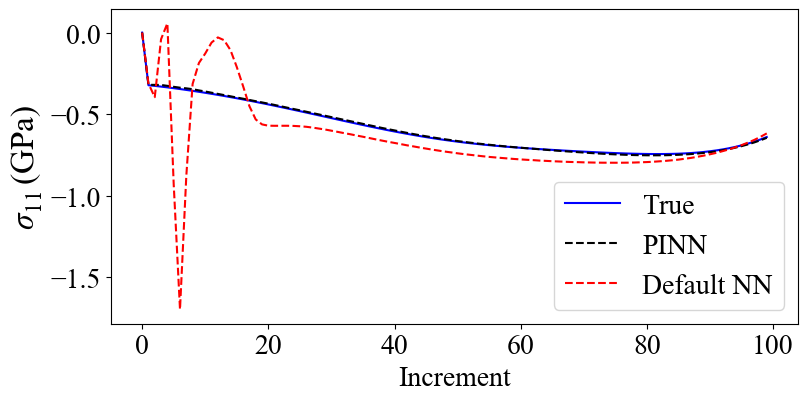

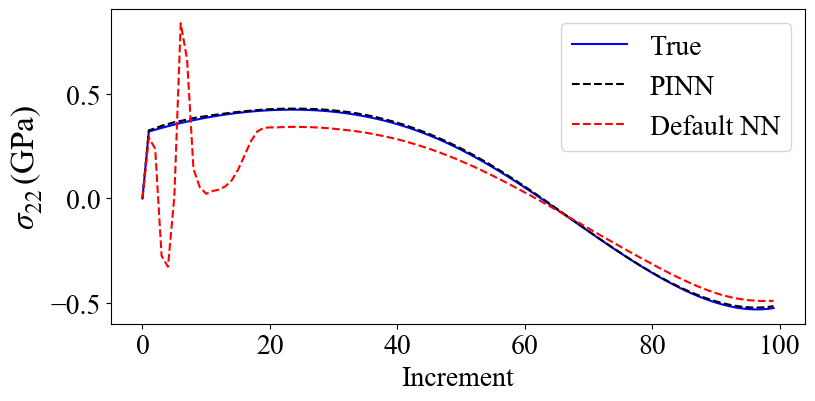

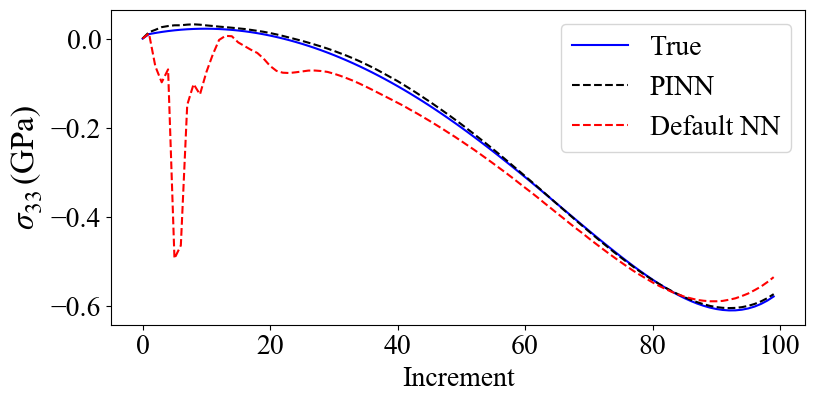

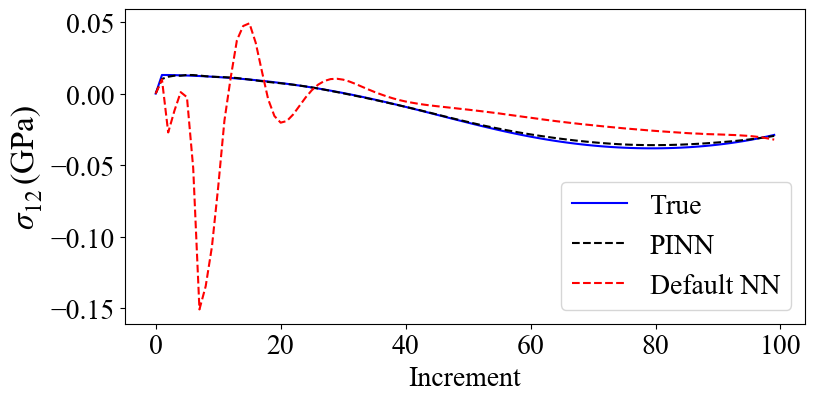

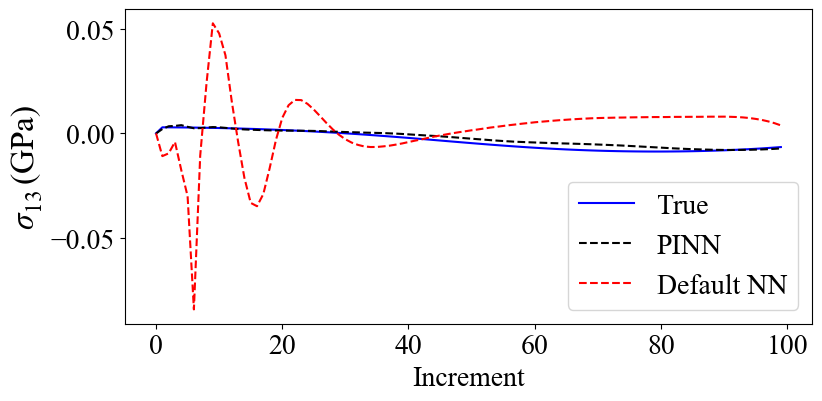

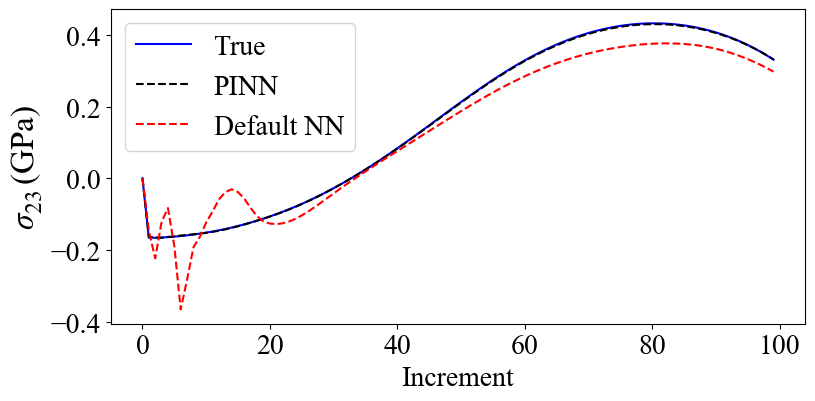

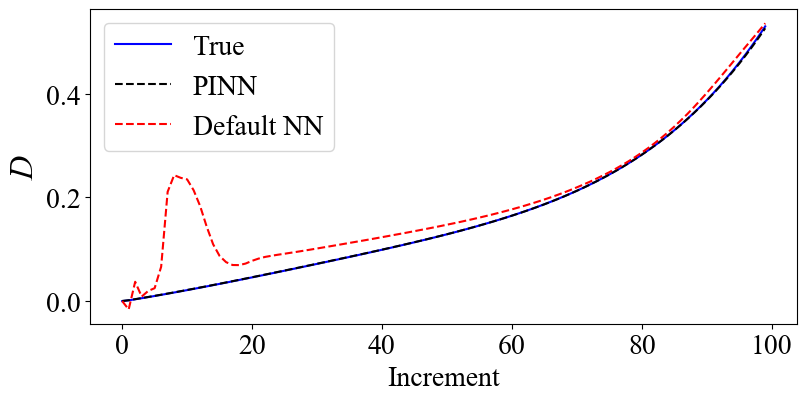

In [9]:
# Inference out of trained region ( starin > 0.2 ) ]
# Note: some points may still lie within the trained domain

# defaul model
model.eval()

# Pick a sample from test data
sample_index = random.randint(1, num_outDoamin_data -1)
print('sample_index =' , sample_index)

X_test_outDoamin = X_test_outDoamin_tens[sample_index].unsqueeze(0).to(device)
Y_test_outDoamin = Y_test_outDoamin_tens[sample_index].cpu().numpy()      # Shape: (T, 8)
print('input = ', X_test_outDoamin[0][:][-1])


# Run model prediction
with torch.no_grad():
    y_pred_outDoamin_default = model(X_test_outDoamin)  # Shape: (1, T, 8)
    y_pred_outDoamin_pinn    = model_pinn(X_test_outDoamin)
    
    y_pred_outDoamin_default = y_pred_outDoamin_default.squeeze(0).cpu().numpy()  # Shape: (T, 8)
    y_pred_outDoamin_pinn    = y_pred_outDoamin_pinn.squeeze(0).cpu().numpy()  # Shape: (T, 8)
    
# back shear components to GPa
Y_test_outDoamin[: , 3:6 ] /= 10
y_pred_outDoamin_default[: , 3:6 ] /= 10
y_pred_outDoamin_pinn[: , 3:6 ] /= 10

plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
plt.rcParams['font.family'] = 'Times New Roman'

labels = [r'$\sigma_{11}\,(\mathrm{GPa})$', r'$\sigma_{22}\,(\mathrm{GPa})$', r'$\sigma_{33}\,(\mathrm{GPa})$', r'$\sigma_{12}\,(\mathrm{GPa})$', r'$\sigma_{13}\,(\mathrm{GPa})$', r'$\sigma_{23}\,(\mathrm{GPa})$', r'$D$']

for i in range(7):
    plt.figure(figsize=(8, 4))
    plt.plot(Y_test_outDoamin[:, i], label='True', color='blue')
    plt.plot(y_pred_outDoamin_pinn[:, i],'--', label='PINN', color='black')
    plt.plot(y_pred_outDoamin_default[:, i],'--', label='Default NN', color='red')
    plt.xlabel('Increment',fontsize=20)
    plt.ylabel(labels[i],fontsize=24)
    plt.legend(fontsize=20)
    plt.tight_layout()
    plt.tick_params(axis='both', labelsize=20)
    filename = os.path.join(save_path_plot_default, f"plot_outDoamin_default_{i}.svg")
    #plt.savefig(filename, format='svg', bbox_inches='tight')
    plt.show()
    
    

In [10]:
# RMSE Default model inside trained domain

RMSE_inside  = []

for i in range(100):
    out = model(X_test_tens[i].to(device))  # (100, 7)
    err = out - Y_test_tens[i].to(device)   # (100, 7)
    mse_per_feature = torch.mean(err**2, dim=0)  # mean over time steps → shape (7,)
    rmse_per_feature = torch.sqrt(mse_per_feature)  # shape (7,)
    RMSE_inside .append(rmse_per_feature)

# Now RMSE is a list of 100 tensors of shape (7,)
# To get RMSE per feature over the entire dataset , average over samples:
RMSE_inside  = torch.stack(RMSE_inside )  # shape (100, 7)
final_rmse_per_feature = torch.mean(RMSE_inside , dim=0)  # shape (7,)

print("RMSE Default model inside trained domain = ",final_rmse_per_feature)


RMSE Default model inside trained domain =  tensor([0.0078, 0.0076, 0.0078, 0.0083, 0.0109, 0.0084, 0.0024],
       device='cuda:0', grad_fn=<MeanBackward1>)


In [11]:
# RMSE Default model outside trained domain

RMSE_outside = []

for i in range(100):
    out = model(X_test_outDoamin_tens[i])  # (100, 7)
    err = out - Y_test_outDoamin_tens[i]   # (100, 7)
    mse_per_feature = torch.mean(err**2, dim=0)  # mean over time steps → shape (7,)
    rmse_per_feature = torch.sqrt(mse_per_feature)  # shape (7,)
    RMSE_outside.append(rmse_per_feature)


RMSE_outside = torch.stack(RMSE_outside)  # shape (100, 7)
final_rmse_per_feature = torch.mean(RMSE_outside, dim=0)  # shape (7,)

print("RMSE Default model outside trained domain = ",final_rmse_per_feature)

RMSE Default model outside trained domain =  tensor([0.0232, 0.0222, 0.0228, 0.0473, 0.0474, 0.0451, 0.0097],
       device='cuda:0', grad_fn=<MeanBackward1>)


In [12]:
# RMSE Default PINN model outside trained domain

RMSE_outside_pinn = []

for i in range(100):
    out = model_pinn(X_test_outDoamin_tens[i])  # (100, 7)
    err = out - Y_test_outDoamin_tens[i]   # (100, 7)
    mse_per_feature = torch.mean(err**2, dim=0)  # mean over time steps → shape (7,)
    rmse_per_feature = torch.sqrt(mse_per_feature)  # shape (7,)
    RMSE_outside_pinn.append(rmse_per_feature)


RMSE_outside_pinn = torch.stack(RMSE_outside_pinn)  # shape (100, 7)
final_rmse_per_feature = torch.mean(RMSE_outside_pinn, dim=0)  # shape (7,)

print("RMSE Default model outside trained domain = ",final_rmse_per_feature)

RMSE Default model outside trained domain =  tensor([0.0136, 0.0136, 0.0139, 0.0100, 0.0110, 0.0107, 0.0043],
       device='cuda:0', grad_fn=<MeanBackward1>)


#### Reload default model after closing


In [ ]:
import torch
import pickle
import torch.nn as nn
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from tqdm import tqdm 
import matplotlib.pyplot as plt
import os


# Step 0: 
Materials = ['Steel' , 'Aluminum_AA7075_T6', 'Aluminum_notched_bar', 'Aluminum_flat_grooved']
material = Materials[0] 


model_filename = "Model_GRU_7000Epock_default_Steel.pth"
session_vars_filename = "session_vars_default_Steel.pkl"


# Step 1: Load variables
with open(session_vars_filename , 'rb') as f:
    session = pickle.load(f)
    
train_losses     = session['train_losses']
lr_vec           = session['lr_vec']
num_epochs       = session['num_epochs']
Y_train_mod      = session['Y_train_mod']
Y_test_mod       = session['Y_test_mod']
Y_valid_mod      = session['Y_valid_mod']
X_train_mod      = session['X_train_mod']
X_test_mod       = session['X_test_mod']
X_valid_mod      = session['X_valid_mod']
input_size       = session['input_size']
num_hidden_units = session['num_hidden_units']
output_size      = session['output_size']

print(input_size,output_size,num_hidden_units)
save_path_plot_default = r"D:\Python\vsCode\PINN\plots_default" 

# Step 2: Recreate the model
class GRUNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(GRUNet, self).__init__()
        self.gru1 = nn.GRU(input_size, hidden_size, batch_first=True)
        self.gru2 = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.gru3 = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x, _ = self.gru1(x)
        x, _ = self.gru2(x)
        x, _ = self.gru3(x)
        x = self.fc(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GRUNet(input_size, num_hidden_units, output_size).to(device)


# Step 3: Load weights
model.load_state_dict(torch.load( model_filename ))
model.eval()

# Step 4: make tensors
X_train_tens = torch.tensor(np.array(X_train_mod), dtype=torch.float32).transpose(1, 2)  # shape: (N, T, 6)
Y_train_tens = torch.tensor(np.array(Y_train_mod), dtype=torch.float32).transpose(1, 2)  # shape: (N, T, 8)
X_test_tens  = torch.tensor(X_test_mod, dtype=torch.float32).to(device).transpose(1, 2)  # NumPy array ----> PyTorch tensor
Y_test_tens  = torch.tensor(Y_test_mod, dtype=torch.float32).to(device).transpose(1, 2)
X_valid_tens = torch.tensor(np.array(X_valid_mod), dtype=torch.float32).transpose(1, 2)
Y_valid_tens = torch.tensor(np.array(Y_valid_mod), dtype=torch.float32).transpose(1, 2)

# ** Go to Inference Cell **
